# Noise testing

To make a brain model behave more like a real system we usually inject some randomness. In practice the integration time step dt is often omitted or handled inconsistently in relation to that noise. This makes the dynamics change when you vary the step length—smaller steps give the noise a proportionally larger impact on the update.

As for all other tutorials in this suite, the expectation is that the model can be instantiated with any set of initial conditions and parameters and that it can advance the state by a single Euler‑integration step using the supplied dt.

Since true hardware‑based randomness (TRNG) is essentially impossible on a computer, we rely on a pseudo‑random number generator (PRNG). A PRNG is just a deterministic function, and with a sufficiently large sample we can talk about its output distribution. Assuming the noise functions are random enough, having the same distribution means they carry the same statistical information. So, to assert that noise is handled the same way in both models, we will compare the results of many one‑step Euler integrations from the same initial starting point, extract the noise distribution, and compare them.

The random‑number generator rng is assumed to be correctly implemented, so it is deliberately ignored in these tests; the focus is solely on the correct handling of dt.

By confirming that the model accepts arbitrary initial conditions and parameters and that a single Euler step yields the same distribution as the ground truth model for a given dt, we verify that the timestep is applied consistently. Passing this check gives confidence that longer simulations will be numerically stable and reproducible across different step sizes, in relation to noise specifically.

## Wrappers

As in all other tests, first we need to write a wrapper for unifying inputs and outputs of the simulators. I found it easiest to just extend the existing ones with noise settings. TVB was easy, as it could use a stochastic integrator with `nsig = 0`, but for Neurolib the process is much more involved, so the rest of the noise configuration is hidden in an if statement.

In [ ]:
import numpy as np
from config import Config
from neurolib.models.hopf import HopfModel

from tvb.simulator import simulator, coupling
from tvb.simulator.integrators import EulerStochastic
from tvb.simulator.monitors import Raw
from tvb.simulator.models.oscillator import SupHopf
import tvb.simulator.lab as tvbl
import scipy

from conn_no_warning import ConnNoWarnings

from graph import graph_noise_comparison


In [10]:
class TvbModel:
    def __init__(self, config: Config):
        self.config = config
        self._configure_sim()

    def _configure_sim(self):
        self.sim = simulator.Simulator(
            connectivity=self.config.conn,
            model=SupHopf(a=np.r_[self.config.a], omega=np.r_[self.config.w]),
            integrator=EulerStochastic(
                dt=self.config.dt,
                noise=tvbl.noise.Additive(
                    nsig=np.r_[self.config.noise],
                    noise_seed=self.config.noise_seed,
                ),
            ),
            initial_conditions=self.config.init_cond,
            conduction_speed=self.config.speed,
            monitors=[Raw()],
            simulation_length=self.config.dt * self.config.sim_steps,
            coupling=coupling.Scaling(a=np.r_[self.config.coupling_strength]),
        )
        self.sim.configure()

    def run(self):
        return self.sim.run()[0][1].T


In [9]:
class NeurolibModel:
    def __init__(self, config: Config):
        self.config = config
        self._configure_sim()

    def _configure_sim(self):
        self.model = HopfModel(
            Cmat=self.config.conn.weights,
            Dmat=self.config.conn.tract_lengths,
        )
        self.model.params["dt"] = self.config.dt
        self.model.params["xs_init"] = self.config.init_cond[:, 0, :, 0].T
        self.model.params["ys_init"] = self.config.init_cond[:, 1, :, 0].T
        self.model.params["duration"] = self.config.dt * self.config.sim_steps
        self.model.params["a"] = self.config.a
        self.model.params["w"] = self.config.w
        self.model.params["coupling"] = "additive"
        self.model.params["K_gl"] = self.config.coupling_strength
        self.model.params["signalV"] = self.config.speed
        if self.config.noise != 0:
            self.model.params["sigma_ou"] = self.config.noise
            self.model.params["x_ou_mean"] = self.config.noise
            self.model.params["y_ou_mean"] = self.config.noise
            self.model.params["x_ou"] = np.random.uniform(
                -self.config.noise, self.config.noise, (self.config.size,)
            )
            self.model.params["y_ou"] = np.random.uniform(
                -self.config.noise, self.config.noise, (self.config.size,)
            )

    def run(self):
        self.model.run()
        return self.model.x


## Configuration

With the wrappers ready, we need to find a way to configure them in the same way. For this we again reuse/extend the Config class used for other tests.

Notably, when testing one step at a time, noise only effects one node. As such, it would be equivalent to test 1 node in 1000 simulations, as it would be to test 1000 nodes once. Except, of course, testing 1000 nodes is notably faster. Secondly, we only care about the noise function, so the initial conditions should be set to the same number across all nodes, and coupling should be eliminated.

Below you can view the parts of the config specific for noise testing.

In [14]:
class ConfigSimplified:
    def __init__(self, initial_conditions_seed, noise_seed=42):
        # ...
        self.speed = 2.0
        self.noise = 0.0
        self.noise_seed = noise_seed
        self.conn = None

    def __config_connectivity(self):
        if self.conn is None:
            self.conn = ConnNoWarnings().from_file()
        np.fill_diagonal(self.conn.weights, 0)  # remove self-connections
        self.conn.speed = np.r_[self.speed]
        self.size = self.conn.weights.shape[0]

    def init_cond_for_noise(self):
        self.conn = ConnNoWarnings()
        self.conn.weights = np.zeros((1000, 1000))
        self.conn.centres_spherical(number_of_regions=1000)
        self.conn.compute_tract_lengths()
        self.conn.compute_region_labels()
        self.conn.try_compute_hemispheres()
        self.conn.configure()
        self.__config_connectivity()
        self.init_cond = np.r_[[[np.zeros((self.size, 1)), np.zeros((self.size, 1))]]]

    # ...


## Testing

With the wrappers and config ready, we can move on to the testing. For comparing distributions unit test style, you can use KS test. For this example, we're comparing TVB against TVB. From code evaluation we know that Neurolib and TVB noise implementation are different, as TVB is not using the Ornstein Ubleck process. 

In [13]:
def run_noise_comparison(initial_conditons_seed, number_of_tests):

    results_no_noise = []
    results_with_noise = []

    config = Config(initial_conditions_seed=initial_conditons_seed)
    config.init_cond_for_noise()

    # Run model with noise
    config.noise_seed = 0
    config.noise = 10.0
    results_with_noise = TvbModel(config).run().flatten()

    # Run model without noise
    config.noise_seed = 0 + number_of_tests
    config.noise = 0.1

    config.noise = 0
    results_no_noise = TvbModel(config).run().flatten()

    # Statistical test
    ks_stat, ks_p = scipy.stats.ks_2samp(results_no_noise, results_with_noise)
    print(f"KS Test → Statistic: {ks_stat:.4f}, p-value: {ks_p:.4e}")

run_noise_comparison(initial_conditons_seed=42, number_of_tests=1000)

KS Test → Statistic: 0.5140, p-value: 8.9500e-121


## Visualizing the differences

If you'd like to view the distributions as graphs, you can plot the results using your favorite way. Below is a histogram comparison.

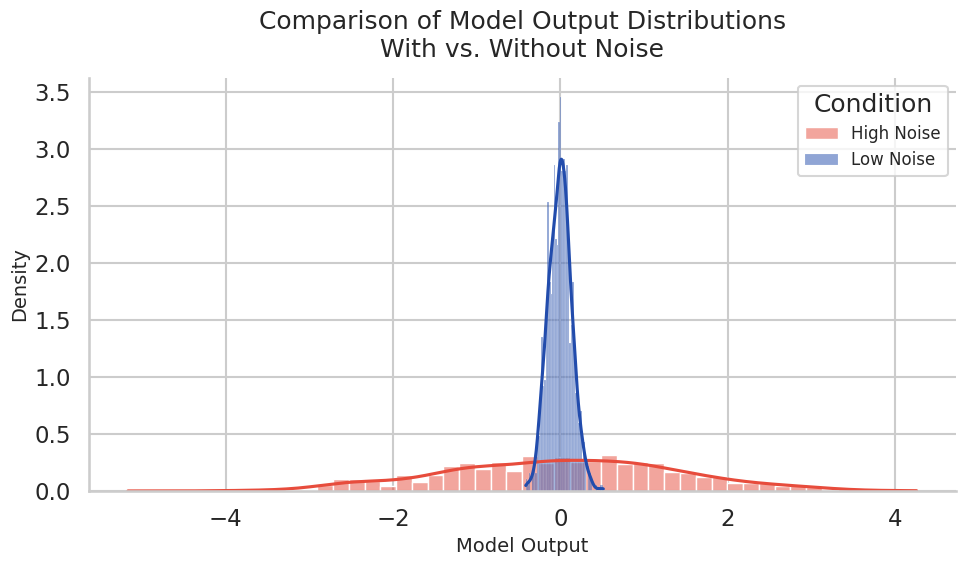

In [ ]:
graph_noise_comparison(initial_conditons_seed=14, number_of_tests=1000)